# 07 — Data Management

This notebook shows how to work with the `tutorial/data/` folder:

1. Generate sample HDF5 files (if not already done)
2. List and browse data files
3. Load an `ExperimentData` from HDF5
4. Compare results across runs
5. Load and inspect a `CalibrationStore`

**Pre-requisite:** run the data generator once:
```bash
cd SQC_soc
python tutorial/data/generate.py
```

In [1]:
import sys, os
sys.path.insert(0, '../')

DATA_DIR = os.path.join(os.path.dirname(os.path.abspath('.')), 'tutorial', 'data')
# If running from inside tutorial/
if not os.path.isdir(DATA_DIR):
    DATA_DIR = 'data'

print('Data directory:', DATA_DIR)
print('Files:', [f for f in os.listdir(DATA_DIR) if not f.startswith('.')])

Data directory: c:\Users\QEL\Desktop\SQC_soc\tutorial\data
Files: ['cal_store_generated.json', 'cal_store_Q1.json', 'generate.py', 'power_rabi.h5', 'qubit_spec.h5', 'ramsey.h5', 'res_spec.h5', 'spin_echo.h5', 'system_cfg_example.py', 't1.h5']


## Step 0 — Generate the sample files (only needed once)

In [2]:
h5_files = [f for f in os.listdir(DATA_DIR) if f.endswith('.h5')]

if not h5_files:
    print('No HDF5 files found — running generator...')
    import subprocess
    result = subprocess.run(
        [sys.executable, os.path.join(DATA_DIR, 'generate.py')],
        capture_output=True, text=True
    )
    print(result.stdout)
    if result.returncode != 0:
        print('STDERR:', result.stderr)
    h5_files = [f for f in os.listdir(DATA_DIR) if f.endswith('.h5')]

print('HDF5 files found:', h5_files)

HDF5 files found: ['power_rabi.h5', 'qubit_spec.h5', 'ramsey.h5', 'res_spec.h5', 'spin_echo.h5', 't1.h5']


## 1. List all data files

In [3]:
from QickworkspaceV2.data.manager import list_data_files

entries = list_data_files(DATA_DIR)

print(f"{'Filename':<30} {'Experiment':<25} {'Timestamp'}")
print('-' * 75)
for e in entries:
    name = os.path.basename(e['path'])
    print(f"{name:<30} {e['experiment']:<25} {e['timestamp']}")

Filename                       Experiment                Timestamp
---------------------------------------------------------------------------
spin_echo.h5                   s007_SpinEcho_ge          2026-05-04T00:27:18.975757
ramsey.h5                      s006_Ramsey_ge            2026-05-04T00:27:18.817931
t1.h5                          s008_T1_ge                2026-05-04T00:27:18.675481
power_rabi.h5                  s005_power_rabi_ge        2026-05-04T00:27:18.646456
qubit_spec.h5                  s003_qubit_spec_ge        2026-05-04T00:27:18.504273
res_spec.h5                    s002_onetone_ge           2026-05-04T00:27:17.183850


## 2. Load a single ExperimentData from HDF5

In [4]:
from QickworkspaceV2 import ExperimentData

t1_path = os.path.join(DATA_DIR, 't1.h5')
t1 = ExperimentData.load(t1_path)

print('Experiment type :', t1.experiment_type)
print('ID              :', t1.experiment_id)
print('Timestamp       :', t1.timestamp)
print('Quality         :', t1.quality)
print('scalar_result   :', t1.scalar_result)
print('fit_result      :', t1.fit_result)
print('x_axis shape    :', t1.x_axis.shape if t1.x_axis is not None else None)
print('Config snapshot :', {k: t1.config[k] for k in list(t1.config)[:5]})

Experiment type : s008_T1_ge
ID              : 4885b1ac
Timestamp       : 2026-05-04 00:27:18.675481
Quality         : QualityFlag.GOOD
scalar_result   : 50.019629343467756
fit_result      : {'T1_us': [50.019629343467756, 0.2535516876014883], 'amplitude': [0.0002193693416805647, 0.0012453535631462656], 'offset': [0.9995363205048896, 0.001987647388207896]}
x_axis shape    : (101,)
Config snapshot : {'name': 'Q1', 'ro_ch': 0, 'res_ch': 0, 'qb_ch': 1, 'res_freq_ge': 6699.998471285255}


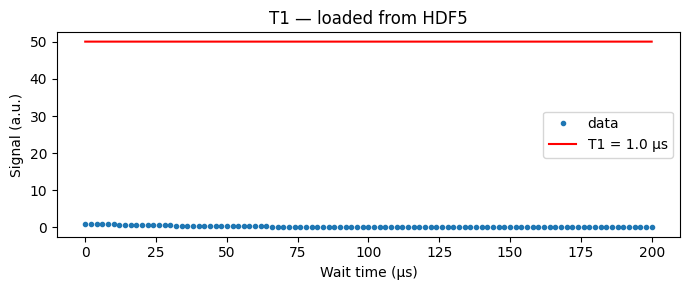

In [5]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(t1.x_axis, np.abs(t1.raw_iq), 'o', ms=3, label='data')

if t1.fit_params is not None and len(t1.fit_params) >= 3:
    A, T1_fit, C = t1.fit_params[:3]
    t_fit = np.linspace(t1.x_axis[0], t1.x_axis[-1], 400)
    ax.plot(t_fit, A * np.exp(-t_fit / T1_fit) + C, 'r-',
            lw=1.5, label=f'T1 = {T1_fit:.1f} µs')

ax.set_xlabel('Wait time (µs)')
ax.set_ylabel('Signal (a.u.)')
ax.set_title('T1 — loaded from HDF5')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Load all experiments and compare scalar results

In [6]:
loaded = {}
for e in entries:
    try:
        data = ExperimentData.load(e['path'])
        key  = os.path.splitext(os.path.basename(e['path']))[0]
        loaded[key] = data
    except Exception as exc:
        print(f'  Could not load {e["path"]}: {exc}')

print(f"{'Name':<20} {'Quality':<12} {'Scalar result'}")
print('-' * 50)
for name, d in loaded.items():
    val = f'{d.scalar_result:.4f}' if d.scalar_result is not None else 'N/A'
    print(f'{name:<20} {d.quality.value:<12} {val}')

Name                 Quality      Scalar result
--------------------------------------------------
spin_echo            good         120.0000
ramsey               good         60.0000
t1                   good         50.0196
power_rabi           good         0.2431
qubit_spec           good         5000.0207
res_spec             bad          6699.9985


## 4. Inspect the CalibrationStore

In [7]:
from QickworkspaceV2 import CalibrationStore

# Try the pre-generated store first, fall back to the hand-crafted example
generated_path = os.path.join(DATA_DIR, 'cal_store_generated.json')
example_path   = os.path.join(DATA_DIR, 'cal_store_Q1.json')

store_path = generated_path if os.path.exists(generated_path) else example_path
store = CalibrationStore(store_path)

print(store)
print()
print(store.summary())

CalibrationStore(path='c:\\Users\\QEL\\Desktop\\SQC_soc\\tutorial\\data\\cal_store_generated.json', qubits=['Q1'], entries=6)

[Q1]
  res_freq_ge                  = 6699.998471285255  @ 2026-05-04T00:27:18.357358
  qb_freq_ge                   = 5000.020682907839  @ 2026-05-04T00:27:18.511274
  pi_gain_ge                   = 0.24313419097204195  @ 2026-05-04T00:27:18.653458
  T1_us                        = 50.019629343467756  @ 2026-05-04T00:27:18.678418
  T2r_us                       = 60.00000245507332  @ 2026-05-04T00:27:18.834939
  T2e_us                       = 120.00000000000001  @ 2026-05-04T00:27:18.983876


In [8]:
# Check which parameters are stale
FRESHNESS = {
    'res_freq_ge': 48,
    'qb_freq_ge':  12,
    'pi_gain_ge':  12,
    'T1_us':       24,
    'T2r_us':      24,
}

for qubit in store.all_qubits():
    print(f'\n[{qubit}]')
    for param, max_h in FRESHNESS.items():
        val   = store.get(qubit, param)
        stale = store.is_stale(qubit, param, max_age_hours=max_h)
        tag   = '*** STALE ***' if stale else 'fresh'
        val_s = f'{val:.4f}' if isinstance(val, float) else str(val)
        print(f'  {param:<20} = {val_s:<10}  [{tag}]')


[Q1]
  res_freq_ge          = 6699.9985   [fresh]
  qb_freq_ge           = 5000.0207   [fresh]
  pi_gain_ge           = 0.2431      [fresh]
  T1_us                = 50.0196     [fresh]
  T2r_us               = 60.0000     [fresh]


## 5. Export to JSON for logging / dashboards

In [9]:
import json

# ExperimentData → JSON-safe dict
t1_dict = t1.to_dict()
print(json.dumps(
    {k: t1_dict[k] for k in ('experiment_type', 'timestamp', 'scalar_result', 'quality')},
    indent=2, default=str
))

{
  "experiment_type": "s008_T1_ge",
  "timestamp": "2026-05-04T00:27:18.675481",
  "scalar_result": 50.019629343467756,
  "quality": "good"
}


In [10]:
# CalibrationStore → flat dict (ready to feed back into ExperimentConfig)
for qubit in store.all_qubits():
    flat = store.to_flat_dict(qubit)
    print(f'{qubit}: {json.dumps(flat, indent=2)}')

Q1: {
  "res_freq_ge": 6699.998471285255,
  "qb_freq_ge": 5000.020682907839,
  "pi_gain_ge": 0.24313419097204195,
  "T1_us": 50.019629343467756,
  "T2r_us": 60.00000245507332,
  "T2e_us": 120.00000000000001
}


## Data folder layout

```
tutorial/data/
├── generate.py              ← run once to create sample .h5 files
├── system_cfg_example.py    ← hardware config template for your lab
├── cal_store_Q1.json        ← hand-crafted example CalibrationStore
├── cal_store_generated.json ← written by generate.py
├── res_spec.h5              \ 
├── qubit_spec.h5             |
├── power_rabi.h5             |  written by generate.py
├── t1.h5                     |
├── ramsey.h5                 |
└── spin_echo.h5             /
```

In a real lab session you would point `DATA_PATH` in `system_cfg.py` to your
data drive (e.g. `D:/data/`).  The `list_data_files()` function recursively
scans any directory for `.h5` files.